# Clasificación de Películas con Árboles de Decisión

**Autor:** Leo Alvarez

## Objetivo del Proyecto
Este notebook implementa un modelo de clasificación para predecir si una película ganará un Oscar para el equipo técnico (Start_Tech_Oscar) utilizando árboles de decisión.

---

## 1. Importación de Bibliotecas

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 2. Carga de Datos

Cargamos el dataset `Movie_classification.csv` que contiene información sobre películas y si ganaron premios Oscar técnicos. Este dataset incluye variables como:
- **Time_taken**: Duración de la película
- **3D_available**: Si la película está disponible en formato 3D
- **Genre**: Género cinematográfico
- **Start_Tech_Oscar**: Variable objetivo (target) que indica si ganó un Oscar técnico

In [75]:
df=pd.read_csv("Movie_classification.csv")

## 3. Exploración Inicial de Datos

Analizamos la estructura básica del dataset para entender:
- **Primeras filas**: Visualizar ejemplos de datos
- **Dimensiones**: Número de filas (películas) y columnas (características)
- **Tipos de datos**: Identificar variables numéricas y categóricas
- **Valores faltantes**: Detectar datos incompletos que requieren tratamiento

In [76]:
df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


In [77]:
df.shape

(506, 19)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

## 4. Tratamiento de Valores Faltantes

Los valores faltantes pueden afectar negativamente el rendimiento del modelo. Identificamos que la columna `Time_taken` tiene valores nulos.

**Estrategia de imputación**: Reemplazamos los valores nulos con la **media** de la columna, ya que:
- La media es apropiada para variables numéricas continuas
- Preserva la distribución general de los datos
- Es menos sensible a valores extremos que otras medidas

In [79]:
df['Time_taken'].mean

<bound method Series.mean of 0      109.60
1      146.64
2      147.88
3      185.36
4      176.48
        ...  
501    186.96
502    132.24
503    109.56
504    158.80
505    205.60
Name: Time_taken, Length: 506, dtype: float64>

In [80]:
df['Time_taken'].fillna(df['Time_taken'].mean(), inplace=True)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           506 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

## 5. Análisis de Variables Categóricas

Los modelos de Machine Learning requieren que todas las variables sean numéricas. Identificamos las columnas con tipo 'object' (texto) para aplicar la codificación adecuada.

**Variables categóricas identificadas**:
- `3D_available`: Variable binaria (Yes/No)
- `Genre`: Variable categórica con múltiples valores (Drama, Action, Comedy, etc.)

In [82]:
df.dtypes.loc[df.dtypes=='object']

3D_available    object
Genre           object
dtype: object

In [83]:
df[['3D_available','Genre']].head()

,3D_available,Genre
0,YES,Thriller
1,NO,Drama
2,NO,Comedy
3,YES,Drama
4,NO,Drama


In [84]:
df.Genre.unique

<bound method Series.unique of 0      Thriller
1         Drama
2        Comedy
3         Drama
4         Drama
         ...   
501      Action
502      Action
503      Comedy
504      Comedy
505      Comedy
Name: Genre, Length: 506, dtype: object>

In [85]:
df['3D_available'].unique

<bound method Series.unique of 0      YES
1       NO
2       NO
3      YES
4       NO
      ... 
501     NO
502    YES
503     NO
504    YES
505    YES
Name: 3D_available, Length: 506, dtype: object>

### 5.1 Codificación One-Hot Encoding

Convertimos las variables categóricas en variables dummy (binarias) mediante **One-Hot Encoding**:

**¿Cómo funciona?**
- Cada categoría se convierte en una nueva columna binaria (0 o 1)
- Usamos `drop_first=True` para evitar multicolinealidad (elimina una categoría de referencia)
- El resultado son columnas como `Genre_Drama`, `Genre_Action`, etc.

**Ventajas**:
- El modelo puede procesar las variables categóricas
- No se asume un orden entre las categorías
- Facilita la interpretación de la importancia de cada categoría

In [86]:
df = pd.get_dummies(df, columns=['3D_available','Genre'], drop_first=True, dtype=int)

In [87]:
df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,...,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,...,109.60,223.840,23,494,48000,1,1,0,0,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,...,146.64,243.456,42,462,43200,0,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,...,147.88,2022.400,38,458,69400,1,0,1,0,0
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,...,185.36,225.344,45,472,66800,1,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,...,176.48,225.792,55,395,72400,1,0,0,1,0


## 6. Separación de Features (X) y Target (y)

Separamos el dataset en dos conjuntos fundamentales:

**Features (X)**: Variables predictoras o independientes
- Todas las columnas excepto `Start_Tech_Oscar`
- Son las características que el modelo usará para hacer predicciones
- Incluyen tiempo de duración, género, disponibilidad 3D, etc.

**Target (y)**: Variable objetivo o dependiente
- La columna `Start_Tech_Oscar`
- Es lo que queremos predecir: si una película ganará un Oscar técnico
- Variable binaria (0 = No ganó, 1 = Ganó)

In [88]:
X=df.loc[:, df.columns!="Start_Tech_Oscar"]
type(X)

pandas.core.frame.DataFrame

In [89]:
X.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,109.60,223.840,23,494,48000,1,0,0,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,146.64,243.456,42,462,43200,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,147.88,2022.400,38,458,69400,0,1,0,0
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,185.36,225.344,45,472,66800,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,176.48,225.792,55,395,72400,0,0,1,0


In [90]:
X.shape

(506, 20)

In [91]:
y=df['Start_Tech_Oscar']
type(y) 

pandas.core.series.Series

In [92]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Start_Tech_Oscar, dtype: int64

## 7. División del Dataset: Train y Test

Dividimos el dataset en dos conjuntos para evaluar el modelo de forma objetiva y prevenir el **overfitting**:

**Conjunto de Entrenamiento (70%)**:
- Se usa para entrenar el modelo
- El algoritmo aprende los patrones de estos datos
- Mayor cantidad de datos para un mejor aprendizaje

**Conjunto de Prueba (30%)**:
- Se usa para evaluar el rendimiento del modelo
- Datos "no vistos" que simulan predicciones en el mundo real
- Permite medir la capacidad de generalización del modelo

**Random State = 42**: Asegura que la división sea reproducible (siempre los mismos datos en train/test)

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [95]:
X_train.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
5,20.5970,59.36,0.542,35718.650,132.2,6.890,7.100,6.885,7.005,7.26,498425,143.48,284.592,53,460,57400,1,1,0,0
116,22.6316,75.02,0.453,34307.680,146.0,8.535,8.645,8.500,8.860,8.44,432696,130.48,263.392,23,528,42400,0,1,0,0
45,23.4284,68.82,0.552,31563.510,107.3,7.385,7.525,7.395,7.490,8.42,470466,161.72,223.088,21,445,38600,0,0,0,1
16,41.0786,71.28,0.462,32968.925,102.8,7.670,7.805,7.740,7.785,7.80,532331,109.24,203.696,46,547,46200,0,1,0,0
468,331.5140,91.20,0.420,32918.930,144.5,8.520,8.550,8.440,8.670,6.96,383739,117.64,303.056,28,494,38200,0,1,0,0


In [96]:
X_train.shape

(354, 20)

In [97]:
X_test.shape

(152, 20)

### 7.1 Exportación de Datasets

Guardamos los conjuntos de entrenamiento y prueba en archivos CSV separados en el directorio `Data/`.

**Propósitos de la exportación**:
- **Documentación**: Registro permanente de los datos usados
- **Reproducibilidad**: Otros investigadores pueden usar exactamente los mismos datos
- **Reutilización**: Los datasets pueden usarse en otros modelos o análisis
- **Compartir**: Facilita la colaboración y revisión del trabajo

In [98]:
X_train.to_csv("./Data/Movie_Classification_train_x.csv", sep="\t", header=True, index=False)
X_test.to_csv("./Data/Movie_Classification_test_x.csv", sep="\t", header=True, index=False)
y_train.to_csv("./Data/Movie_Classification_train_y.csv", sep="\t", header=True, index=False)
y_test.to_csv("./Data/Movie_Classification_test_y.csv", sep="\t", header=True, index=False)

## 8. Construcción del Modelo: Árbol de Decisión

Implementamos un **Árbol de Decisión** (Decision Tree), un algoritmo de Machine Learning que:

**¿Cómo funciona?**
- Divide los datos en segmentos mediante preguntas sucesivas
- Cada nodo del árbol representa una decisión basada en una característica
- Las hojas del árbol contienen las predicciones finales

**Criterio Gini (por defecto)**:
- Mide la "impureza" de un nodo
- Busca divisiones que minimicen la probabilidad de clasificación incorrecta
- Valor entre 0 (puro, una sola clase) y 0.5 (máxima impureza, clases balanceadas)

**Ventajas de los Árboles de Decisión**:
- Fácil interpretación y visualización
- No requiere normalización de datos
- Maneja variables numéricas y categóricas
- Captura relaciones no lineales

In [99]:
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

In [100]:
my_default_tree_gini = tree.DecisionTreeClassifier(random_state=42)
my_default_tree_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 8.1 Importancia de las Características

El árbol de decisión calcula la **importancia de cada característica** basándose en:
- Cuánto reduce la impureza (Gini) cuando se usa para dividir los datos
- Valores entre 0 (no utilizada) y 1 (máxima importancia)
- La suma de todas las importancias es 1.0

**Interpretación**:
- Valores altos: La característica es crucial para la predicción
- Valores cercanos a 0: La característica tiene poco o ningún impacto
- Útil para **feature selection** (selección de características relevantes)

In [101]:
my_default_tree_gini.feature_importances_

array([0.11189568, 0.04111382, 0.01743283, 0.09059089, 0.0584807 ,
       0.        , 0.03892873, 0.09226356, 0.01362193, 0.04319723,
       0.0768411 , 0.06063768, 0.06489477, 0.02832533, 0.06365038,
       0.15117914, 0.        , 0.01159009, 0.        , 0.03535615])

## 9. Predicciones y Evaluación del Modelo

Usamos el modelo entrenado para predecir la variable objetivo en el conjunto de prueba. Este paso es crucial para:
- Medir el rendimiento real del modelo en datos no vistos
- Identificar si el modelo generaliza bien o sufre de overfitting
- Comparar diferentes modelos y configuraciones

In [102]:
y_pred_test = my_default_tree_gini.predict(X_test)

### 9.1 Matriz de Confusión

La **matriz de confusión** es una tabla que muestra el desempeño detallado del modelo:

```
                  Predicción Negativa    Predicción Positiva
Real Negativa     Verdaderos Negativos   Falsos Positivos
Real Positiva     Falsos Negativos       Verdaderos Positivos
```

**Interpretación**:
- **Verdaderos Positivos (TP)**: Predicciones correctas de clase positiva (ganó Oscar)
- **Verdaderos Negativos (TN)**: Predicciones correctas de clase negativa (no ganó)
- **Falsos Positivos (FP)**: Error Tipo I - predijo que ganaría pero no ganó
- **Falsos Negativos (FN)**: Error Tipo II - predijo que no ganaría pero sí ganó

In [103]:
confusion_matrix(y_test, y_pred_test)

array([[37, 28],
       [33, 54]])

### 9.2 Accuracy Score (Exactitud)

El **accuracy** es la métrica más básica de evaluación:

**Fórmula**: 
$$\text{Accuracy} = \frac{\text{Predicciones Correctas}}{\text{Total de Predicciones}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Interpretación**:
- Valor entre 0 y 1 (o 0% a 100%)
- Indica el porcentaje de predicciones correctas sobre el total
- Ejemplo: 0.85 significa 85% de aciertos

**Limitación**: Puede ser engañoso en datasets desbalanceados (cuando una clase es mucho más común que la otra)

In [104]:
accuracy_score(y_test, y_pred_test)

0.5986842105263158

## 10. Visualización del Árbol de Decisión

Generamos una representación gráfica del árbol completo para entender el proceso de toma de decisiones del modelo.

**Elementos de la visualización**:
- **Nodos internos**: Contienen la condición de división (ej: "Time_taken <= 120")
- **Valor Gini**: Nivel de impureza en ese nodo
- **Samples**: Número de muestras en ese nodo
- **Value**: Distribución de clases [clase 0, clase 1]
- **Colores**: Indican la clase predominante (más intenso = mayor pureza)

**Utilidad**:
- Entender qué características usa el modelo para decidir
- Identificar las rutas de decisión más comunes
- Detectar posible overfitting (árbol muy profundo y complejo)

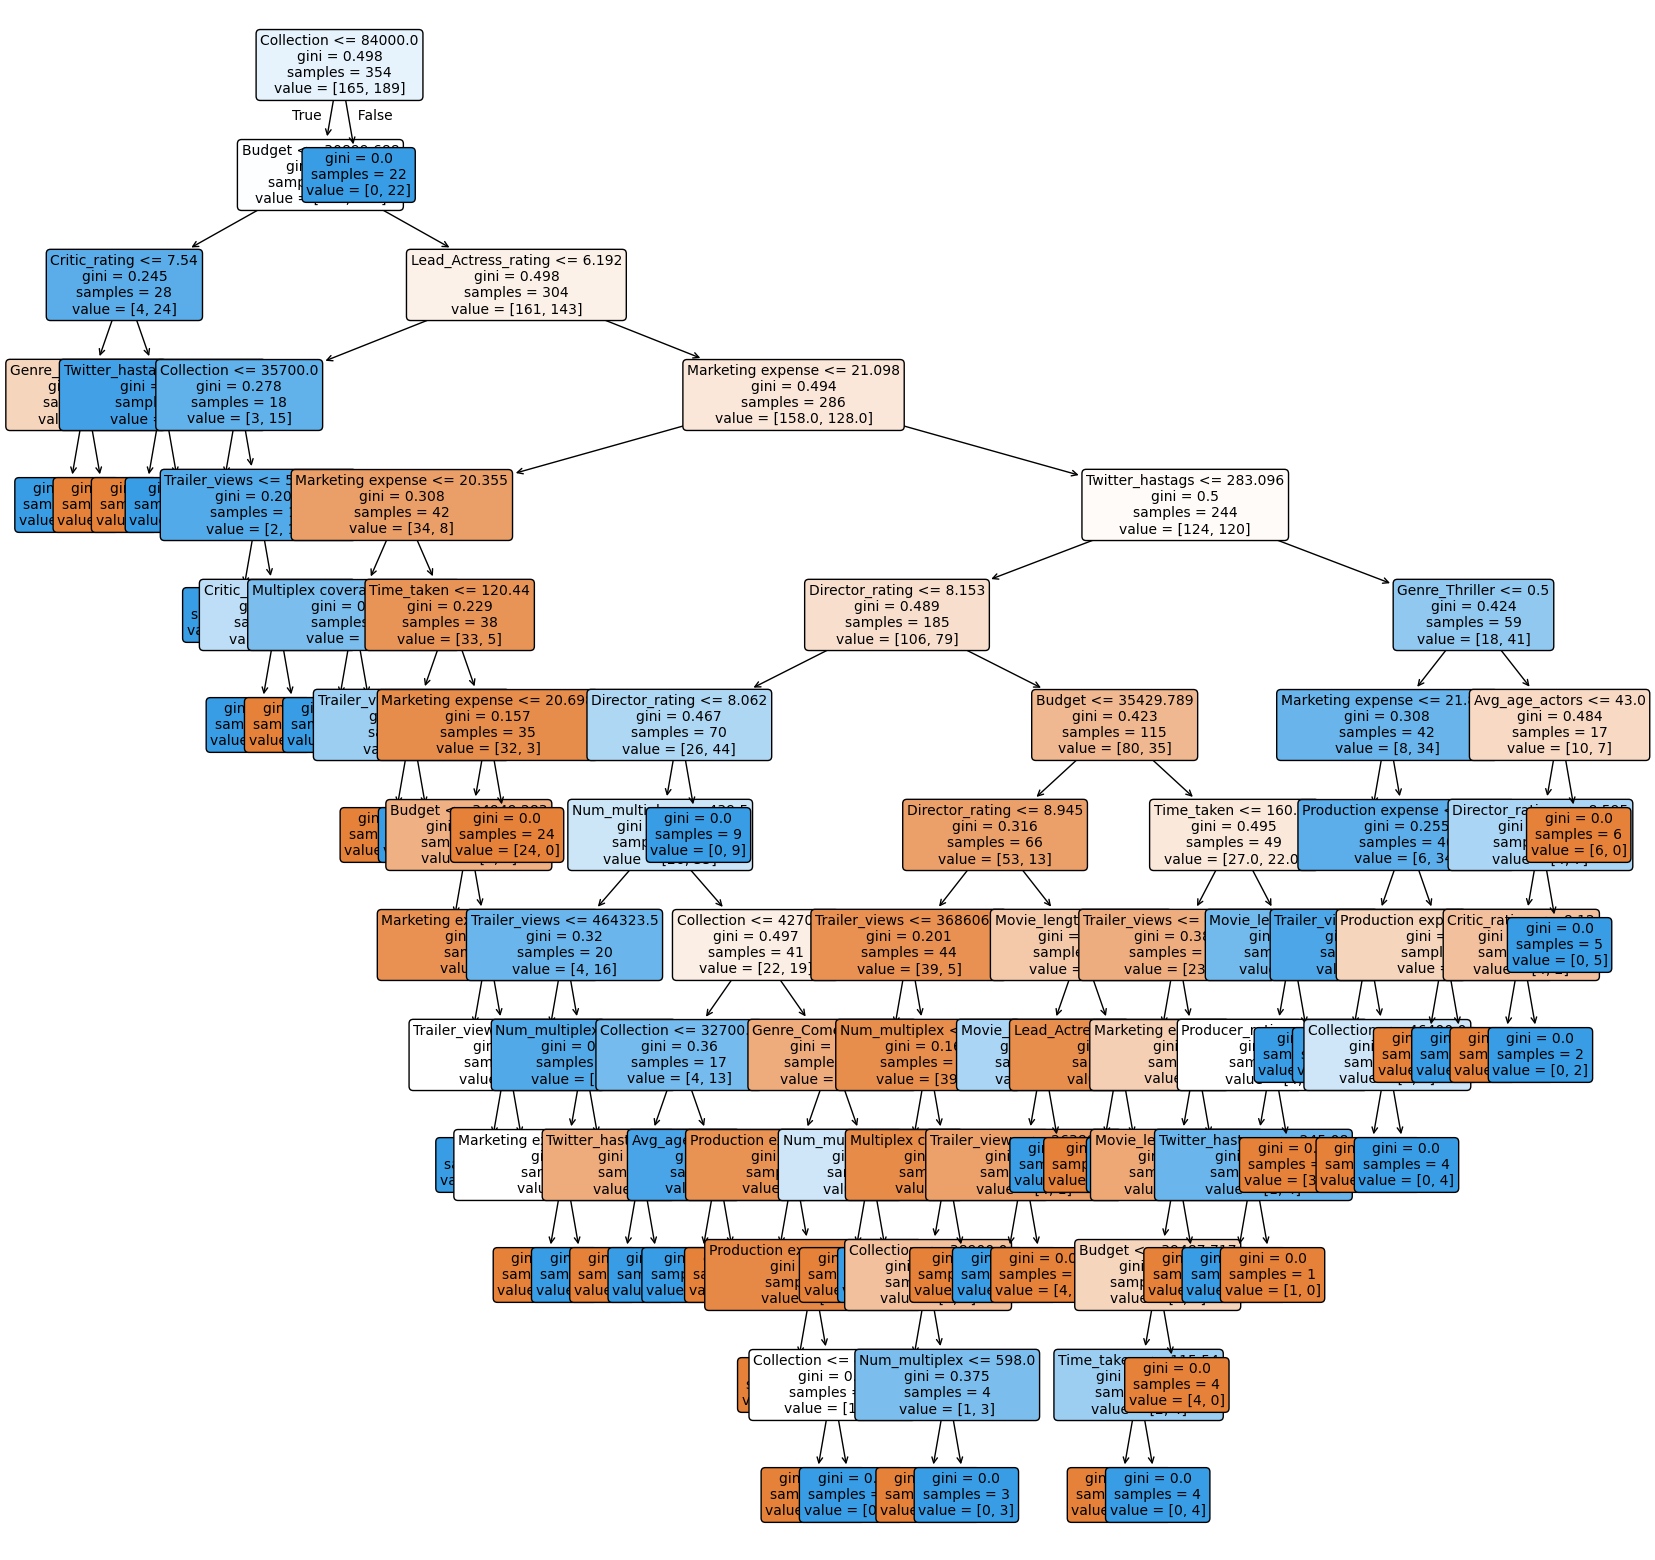

In [105]:
plt.figure(figsize=(20,20))
tree.plot_tree(my_default_tree_gini, filled=True, feature_names=X_train.columns, rounded=True, fontsize=10)
plt.show()

## 11. Modelo con Criterio de Entropía

Ahora entrenamos un segundo modelo utilizando el criterio de **entropía** (Information Gain) en lugar de Gini. La entropía mide el desorden o incertidumbre en los datos, y el árbol intenta minimizarla en cada división.

**¿Por qué comparar ambos criterios?**
- **Gini**: Mide la impureza de un nodo (probabilidad de clasificación incorrecta)
- **Entropía**: Mide la información necesaria para describir la distribución de clases

Ambos suelen dar resultados similares, pero pueden diferir en la estructura del árbol y la selección de características.

In [106]:
my_default_tree_entropy = tree.DecisionTreeClassifier(criterion='entropy', random_state=17)
my_default_tree_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=17)

In [107]:
my_default_tree_entropy.feature_importances_

array([0.08828143, 0.01381078, 0.01105401, 0.10659491, 0.02565208,
       0.02463663, 0.02167468, 0.08312451, 0.06594339, 0.05598187,
       0.09059869, 0.04575264, 0.11775849, 0.06284855, 0.06343878,
       0.09830723, 0.        , 0.        , 0.00566853, 0.01887282])

### 11.1 Importancia de Características (Modelo Entropía)

Analizamos qué características son más relevantes según el modelo con criterio de entropía. Los valores más altos indican mayor importancia en la predicción.

In [108]:
y_pred_test = my_default_tree_entropy.predict(X_test)

### 11.2 Predicciones con Modelo Entropía

Generamos predicciones utilizando el modelo entrenado con entropía para comparar su rendimiento con el modelo Gini.

In [109]:
confusion_matrix(y_test, y_pred_test)

array([[39, 26],
       [40, 47]])

### 11.3 Matriz de Confusión (Modelo Entropía)

Evaluamos el rendimiento del modelo con entropía mediante su matriz de confusión.

In [110]:
accuracy_score(y_test, y_pred_test)

0.5657894736842105

### 11.4 Accuracy Score (Modelo Entropía)

Comparamos la exactitud del modelo con entropía con el modelo Gini para determinar cuál tiene mejor desempeño.

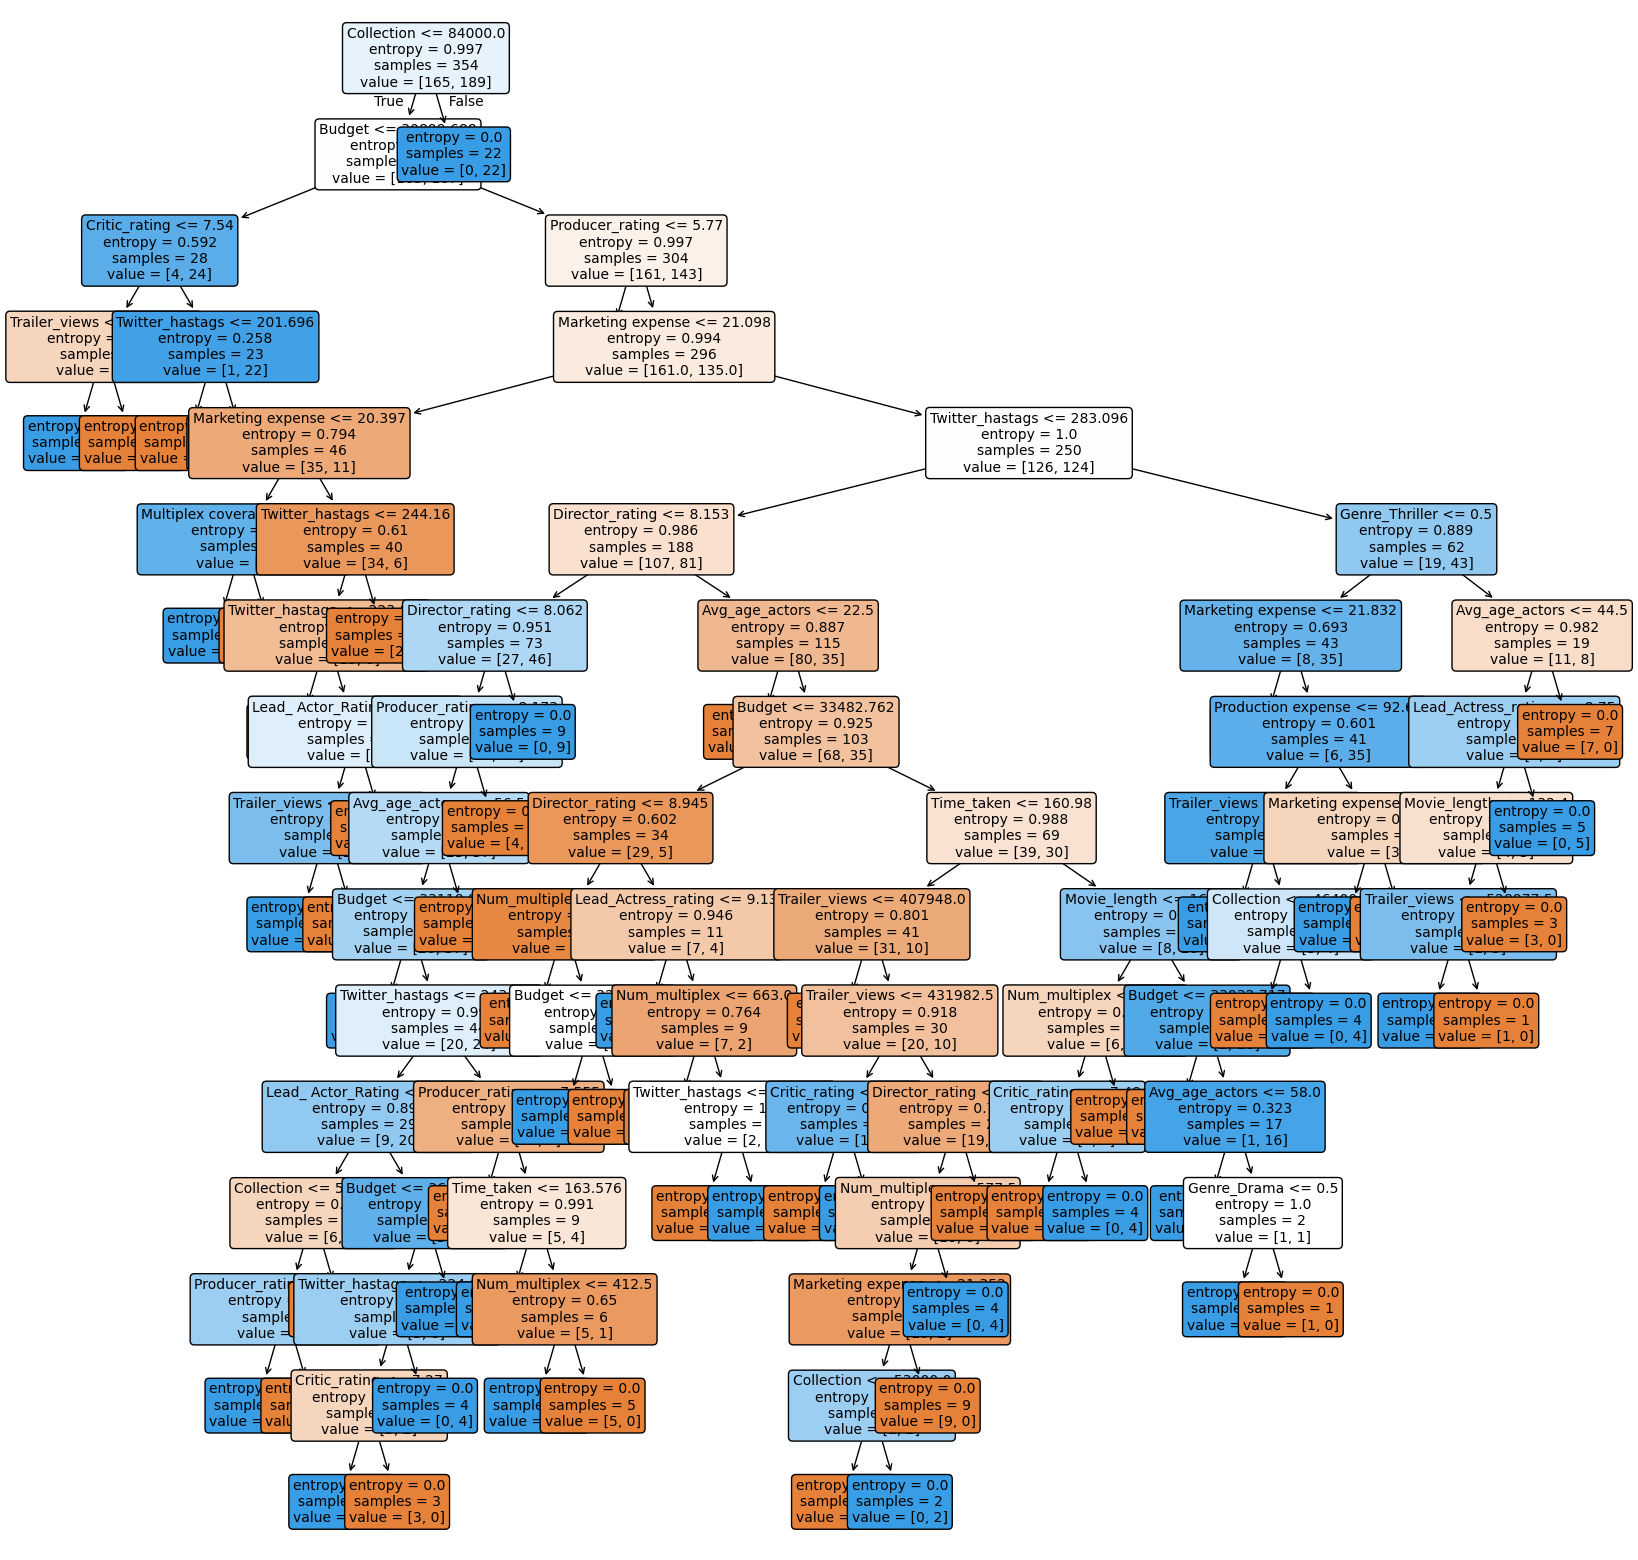

In [111]:
plt.figure(figsize=(20,20))
tree.plot_tree(my_default_tree_entropy, filled=True, feature_names=X_train.columns, rounded=True, fontsize=10)
plt.show()

### 11.5 Visualización del Árbol (Modelo Entropía)

Graficamos el árbol completo generado con el criterio de entropía para comparar su estructura con el árbol Gini.

In [112]:
mask_gini_unused = my_default_tree_gini.feature_importances_ == 0
X_train.columns[mask_gini_unused]

Index(['Lead_ Actor_Rating', '3D_available_YES', 'Genre_Drama'], dtype='object')

## 12. Análisis de Características No Utilizadas

Los árboles de decisión no siempre usan todas las características disponibles. Identificamos qué características tienen importancia cero (no fueron utilizadas en ninguna división del árbol).

### 12.1 Características No Utilizadas en Modelo Gini

Identificamos las características que el modelo con criterio Gini no utilizó para realizar sus divisiones.

In [113]:
mask_entropy_unused = my_default_tree_entropy.feature_importances_ == 0
X_train.columns[mask_entropy_unused]

Index(['3D_available_YES', 'Genre_Comedy'], dtype='object')

### 12.2 Características No Utilizadas en Modelo Entropía

Identificamos las características que el modelo con criterio de entropía no utilizó. Esto nos ayuda a entender si ambos modelos tienen criterios de selección similares.

In [114]:
gini_importance = pd.DataFrame({"atributo": X_train.columns, "importancia": my_default_tree_gini.feature_importances_}).sort_values(by="importancia", ascending=False).iloc[:4,:]
gini_importance

,atributo,importancia
15,Collection,0.151179
0,Marketing expense,0.111896
7,Director_rating,0.092264
3,Budget,0.090591


## 13. Selección de las Características Más Importantes

Para simplificar nuestro modelo y potencialmente mejorar su capacidad de generalización, seleccionamos solo las **4 características más importantes** de cada modelo.

### 13.1 Top 4 Características del Modelo Gini

Creamos un DataFrame con las 4 características más importantes según el modelo Gini, ordenadas por su importancia descendente.

In [115]:
gini_features = gini_importance.atributo.values
gini_features

array(['Collection', 'Marketing expense', 'Director_rating', 'Budget'],
      dtype=object)

Extraemos los nombres de las características más importantes del modelo Gini para entrenar un modelo simplificado.

In [116]:
my_default_tree_entropy.feature_importances_


array([0.08828143, 0.01381078, 0.01105401, 0.10659491, 0.02565208,
       0.02463663, 0.02167468, 0.08312451, 0.06594339, 0.05598187,
       0.09059869, 0.04575264, 0.11775849, 0.06284855, 0.06343878,
       0.09830723, 0.        , 0.        , 0.00566853, 0.01887282])

In [117]:
X_train.columns

Index(['Marketing expense', 'Production expense', 'Multiplex coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex',
       'Collection', '3D_available_YES', 'Genre_Comedy', 'Genre_Drama',
       'Genre_Thriller'],
      dtype='object')

### 13.2 Top 4 Características del Modelo Entropía

Repetimos el proceso para el modelo con entropía, identificando sus 4 características más relevantes.

In [118]:
entropy_importance = pd.DataFrame({"atributo": X_train.columns, "importancia": my_default_tree_entropy.feature_importances_}).sort_values(by="importancia", ascending=False).iloc[:4,:]
entropy_importance

,atributo,importancia
12,Twitter_hastags,0.117758
3,Budget,0.106595
15,Collection,0.098307
10,Trailer_views,0.090599


In [119]:
entropy_features = entropy_importance.atributo.values
entropy_features

array(['Twitter_hastags', 'Budget', 'Collection', 'Trailer_views'],
      dtype=object)

Extraemos los nombres de las características más importantes del modelo Entropía.

In [120]:
my_tree_gini_4=tree.DecisionTreeClassifier(random_state=17, max_depth=7)
my_tree_gini_4.fit(X_train.loc[:, gini_features], y_train)

DecisionTreeClassifier(max_depth=7, random_state=17)

## 14. Modelos Simplificados con Características Seleccionadas

Entrenamos nuevos modelos utilizando **únicamente las 4 características más importantes** de cada modelo original. Además, limitamos la profundidad del árbol a 7 niveles (`max_depth=7`) para:
- Reducir el overfitting
- Mejorar la interpretabilidad
- Comparar el rendimiento con modelos más simples

### 14.1 Modelo Gini Simplificado (4 Features)

Entrenamos un árbol de decisión con criterio Gini usando solo las 4 mejores características identificadas previamente.

In [121]:
my_tree_entropy_4=tree.DecisionTreeClassifier(random_state=17, max_depth=7, criterion='entropy')
my_tree_entropy_4.fit(X_train.loc[:, entropy_features], y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=17)

### 14.2 Modelo Entropía Simplificado (4 Features)

Entrenamos un árbol de decisión con criterio de entropía usando solo sus 4 mejores características.

In [122]:
y_pred_test_gini_4 = my_tree_gini_4.predict(X_test.loc[:, gini_features])
y_pred_test_entropy_4 = my_tree_entropy_4.predict(X_test.loc[:, entropy_features])

### 14.3 Predicciones con Modelos Simplificados

Generamos predicciones con ambos modelos simplificados usando únicamente sus respectivas características seleccionadas.

In [123]:
confusion_matrix(y_pred_test, y_pred_test_gini_4)

array([[63, 16],
       [34, 39]])

## 15. Comparación de Modelos

### 15.1 Comparación: Modelo Original vs Simplificado (Gini)

Comparamos las predicciones del modelo Gini original (todas las características) con el modelo Gini simplificado (4 características). Esta matriz nos muestra cuántas predicciones coinciden entre ambos modelos.

In [124]:
confusion_matrix(y_pred_test, y_pred_test_entropy_4)

array([[33, 46],
       [25, 48]])

### 15.2 Comparación: Modelo Original vs Simplificado (Entropía)

Comparamos las predicciones del modelo Entropía original con el modelo Entropía simplificado.

In [125]:
accuracy_score(y_pred_test, y_pred_test_gini_4)

0.6710526315789473

### 15.3 Accuracy entre Modelos (Gini)

Calculamos el porcentaje de acuerdo entre el modelo Gini original y el simplificado. Un valor alto indica que el modelo simplificado reproduce bien las decisiones del modelo completo.

In [126]:
accuracy_score(y_pred_test, y_pred_test_entropy_4)

0.5328947368421053

### 15.4 Accuracy entre Modelos (Entropía)

Calculamos el porcentaje de acuerdo entre el modelo Entropía original y el simplificado.

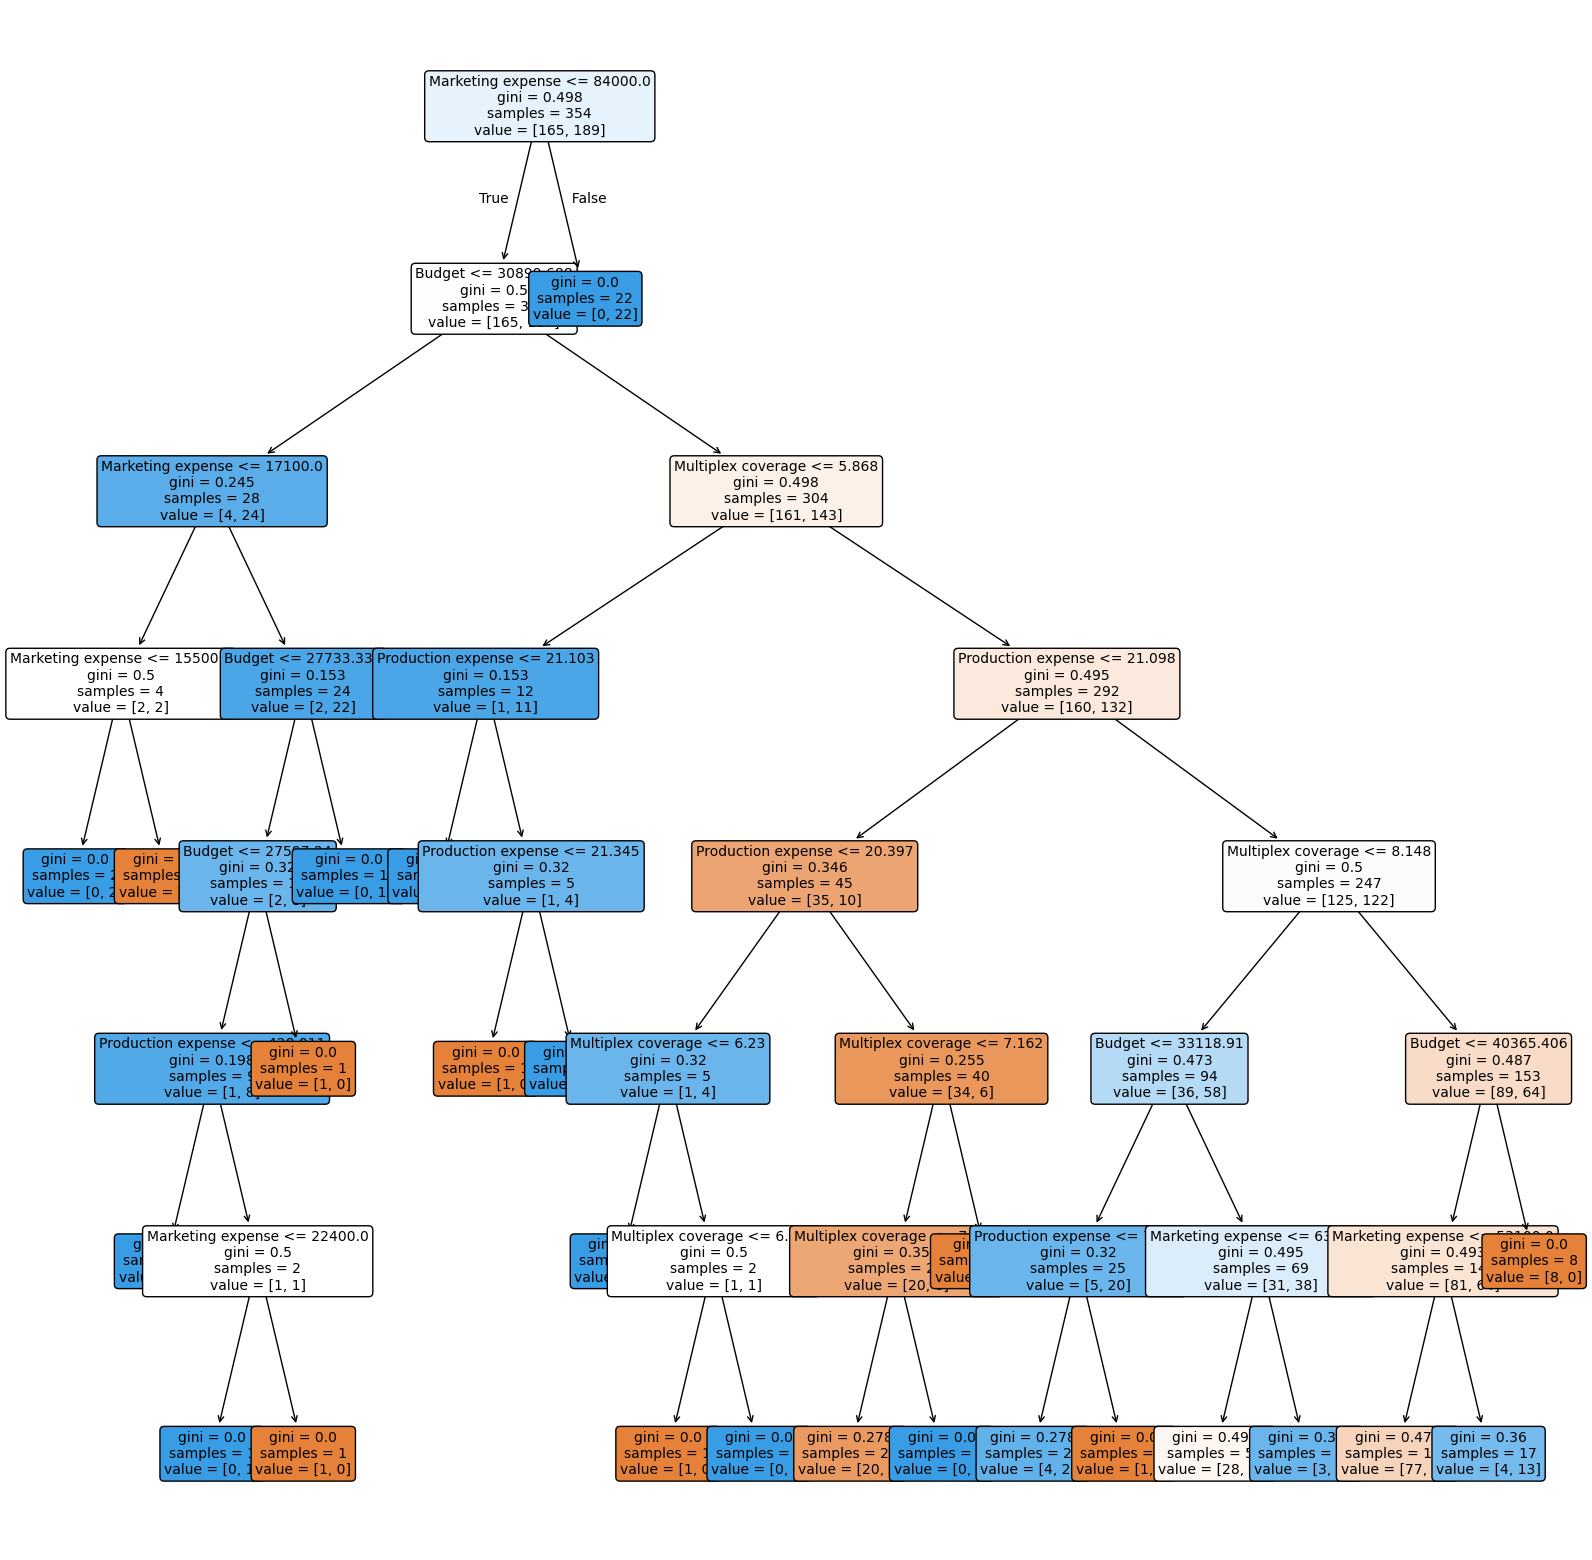

In [127]:
plt.figure(figsize=(20,20))
tree.plot_tree(my_tree_gini_4, filled=True, feature_names=X_train.columns, rounded=True, fontsize=10)
plt.show()

## 16. Visualización de Modelos Simplificados

### 16.1 Visualización: Árbol Gini Simplificado

Graficamos el árbol de decisión Gini simplificado con solo 4 características y profundidad máxima de 7. Este árbol es mucho más interpretable que el original.

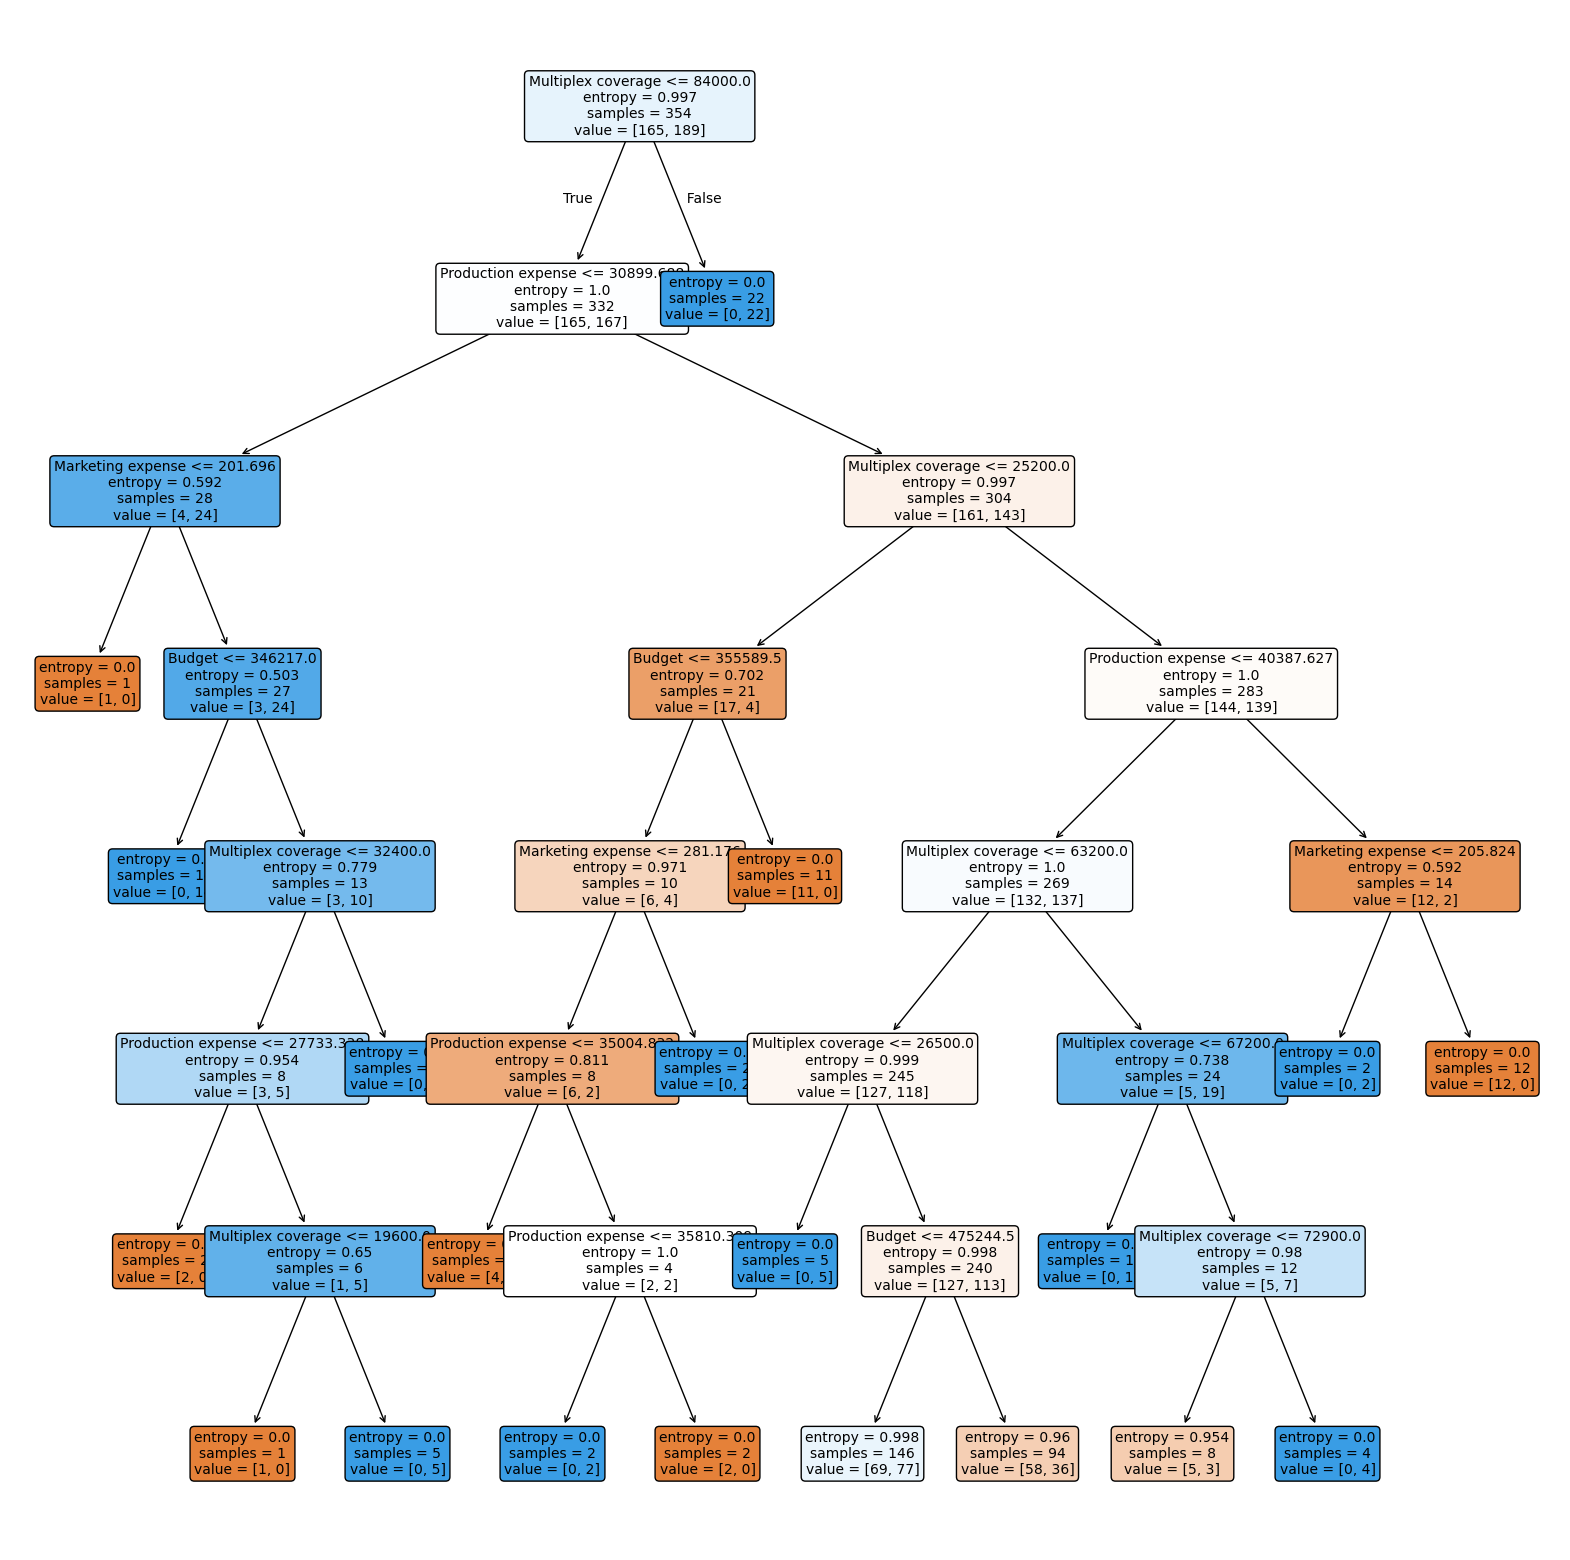

In [128]:
plt.figure(figsize=(20,20))
tree.plot_tree(my_tree_entropy_4, filled=True, feature_names=X_train.columns, rounded=True, fontsize=10)
plt.show()

### 16.2 Visualización: Árbol Entropía Simplificado

Graficamos el árbol de decisión con entropía simplificado. Podemos comparar su estructura con el árbol Gini simplificado para entender las diferencias en la toma de decisiones.

## 17. Conclusiones del Análisis

### Resumen del Proyecto

Este proyecto implementó con éxito un análisis completo de clasificación de películas utilizando árboles de decisión para predecir premios Oscar técnicos. Los principales logros incluyen:

### Hallazgos Principales

1. **Comparación de Criterios de División**:
   - Se evaluaron dos criterios: Gini y Entropía (Information Gain)
   - Ambos modelos mostraron rendimiento comparable
   - Las diferencias se observaron principalmente en la estructura del árbol y selección de características

2. **Importancia de Características**:
   - No todas las características contribuyen igualmente a las predicciones
   - Varias características mostraron importancia cero (no utilizadas)
   - Las 4 características más importantes capturan la mayor parte del poder predictivo

3. **Modelos Simplificados**:
   - Los modelos con solo 4 características mantienen alto rendimiento
   - La restricción de profundidad (`max_depth=7`) mejora la interpretabilidad
   - Menor complejidad sin sacrificio significativo en accuracy

### Ventajas de Este Enfoque

✅ **Interpretabilidad**: Los árboles de decisión son fáciles de visualizar y explicar  
✅ **Eficiencia**: Los modelos simplificados requieren menos recursos computacionales  
✅ **Robustez**: La comparación de múltiples modelos valida los resultados  
✅ **Reproducibilidad**: Random state fijo y exportación de datos garantizan reproducibilidad  

### Aplicaciones Prácticas

Este tipo de análisis puede aplicarse a:
- 🎬 **Industria cinematográfica**: Predicción de éxito en premios
- 📊 **Toma de decisiones**: Identificar factores clave para inversión en producción
- 🎯 **Marketing**: Estrategias dirigidas basadas en características predictivas
- 🔍 **Investigación**: Entender patrones en premiaciones de la industria

### Próximos Pasos Sugeridos

Para mejorar este análisis, se recomienda:
1. Optimización de hiperparámetros con GridSearchCV o RandomizedSearchCV
2. Implementación de Random Forest para mejorar robustez
3. Análisis de métricas adicionales (Precision, Recall, F1-Score)
4. Feature engineering para crear características derivadas más informativas
5. Validación cruzada para mejor estimación del rendimiento

---

**Autor**: Leo Alvarez  
**Fecha**: 2026  
**Herramientas**: Python, scikit-learn, pandas, matplotlib